# Notebook 01 — EDA & Analyses Statistiques
**Projet :** Analyse comparative des pays pour l'investissement et la qualité de vie


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

FINAL_DIR = os.path.join('..', 'data', 'final')
PLOTS_DIR = os.path.join('..', 'reports', 'plots')
os.makedirs(PLOTS_DIR, exist_ok=True)
print('Librairies chargées ✅')

Librairies chargées ✅


## 1. Chargement des données

In [2]:
df = pd.read_csv(os.path.join(FINAL_DIR, 'master_dataset.csv'))
print(f'Dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'Pays    : {df["country_code"].nunique()}')
print(f'Années  : {sorted(df["year"].dropna().unique().astype(int))}')
df.head()

Dataset : 1222 lignes × 21 colonnes
Pays    : 169
Années  : [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,country_code,year,gdp_growth,inflation,population,gni_per_capita,life_expectancy,literacy_rate,country_name,region,...,gdp_per_capita,happiness_score,social_support,life_expectancy_whr,freedom,generosity,corruption,positive_affect,negative_affect,attractivity_score
0,ABW,2015,3.611480,NaN,107906.0,25430.0,NaN,NaN,Aruba,Latin America & Caribbean,...,27458.220154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.523049
1,ABW,2016,1.234335,NaN,108727.0,25560.0,NaN,NaN,Aruba,Latin America & Caribbean,...,27441.550214,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.523035
2,ABW,2017,3.493430,NaN,108735.0,26460.0,NaN,NaN,Aruba,Latin America & Caribbean,...,28440.041688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.523910
3,ABW,2018,3.212471,NaN,108908.0,27970.0,NaN,NaN,Aruba,Latin America & Caribbean,...,30082.158423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.525349
4,ABW,2019,1.225112,NaN,109203.0,29320.0,NaN,NaN,Aruba,Latin America & Caribbean,...,30645.890602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.525843


In [13]:
best_year_hap = df.dropna(subset=['happiness_score']).groupby('year').size().idxmax()
latest_year = best_year_hap
print(f"Année utilisée : {latest_year}")

Année utilisée : 2019


## 2. Valeurs manquantes

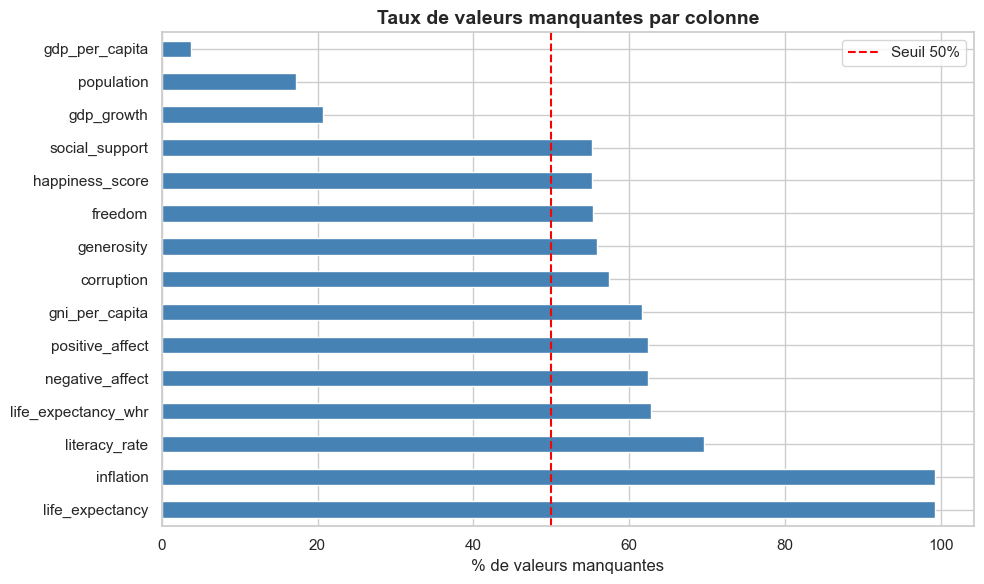

life_expectancy        99.3
inflation              99.2
literacy_rate          69.6
life_expectancy_whr    62.8
negative_affect        62.4
positive_affect        62.4
gni_per_capita         61.7
corruption             57.4
generosity             55.9
freedom                55.4
happiness_score        55.2
social_support         55.2
gdp_growth             20.7
population             17.3
gdp_per_capita          3.7


In [3]:
missing_pct = (df.isnull().mean() * 100).round(1).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 6))
missing_pct.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Taux de valeurs manquantes par colonne', fontsize=14, fontweight='bold')
ax.axvline(x=50, color='red', linestyle='--', label='Seuil 50%')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '01_missing_values.png'), dpi=150, bbox_inches='tight')
plt.show()
print(missing_pct.to_string())

## 3. Statistiques descriptives

In [4]:
kpi_cols = ['gdp_per_capita', 'gdp_growth', 'inflation', 'happiness_score',
            'social_support', 'freedom', 'corruption', 'life_expectancy', 'attractivity_score']
kpi_available = [c for c in kpi_cols if c in df.columns]
df[kpi_available].describe().round(2)

,gdp_per_capita,gdp_growth,inflation,happiness_score,social_support,freedom,corruption,life_expectancy,attractivity_score
count,1177.00,969.00,10.00,548.00,548.00,545.00,520.00,9.00,1222.00
mean,17825.83,2.77,2.48,5.53,0.81,0.78,0.73,62.91,0.51
std,22824.35,5.47,5.77,1.07,0.12,0.12,0.18,1.82,0.07
min,219.42,-23.90,-6.60,2.38,0.42,0.30,0.05,60.42,0.11
25%,2962.99,0.98,-0.34,4.76,0.73,0.71,0.67,62.27,0.50
50%,7099.78,3.08,3.34,5.48,0.83,0.80,0.78,62.44,0.51
75%,24280.06,5.01,5.09,6.31,0.91,0.88,0.85,62.94,0.53
max,142855.37,63.33,13.71,7.89,0.98,0.98,0.96,66.04,0.75


## 4. Distribution des variables clés

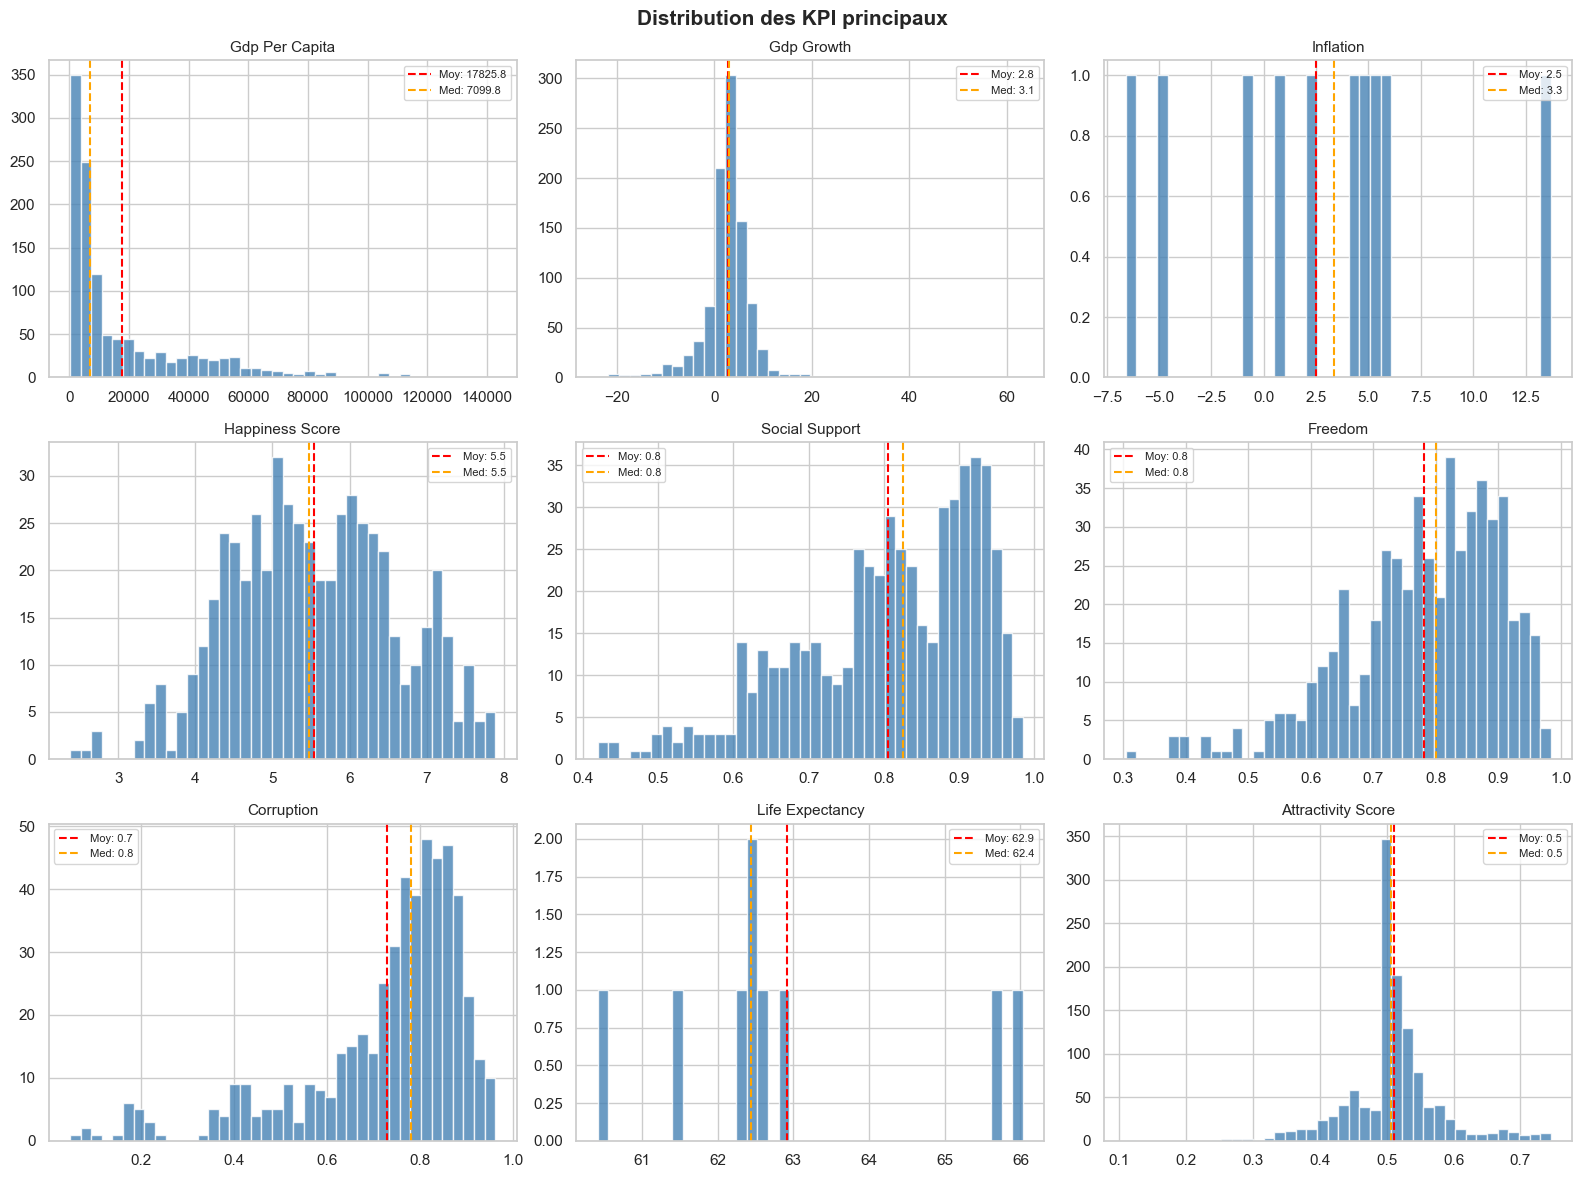

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(kpi_available[:9]):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Moy: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='--', label=f'Med: {data.median():.1f}')
    ax.set_title(col.replace('_', ' ').title(), fontsize=11)
    ax.legend(fontsize=8)

for j in range(len(kpi_available[:9]), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribution des KPI principaux', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '02_distributions_kpi.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Matrice de corrélations
> Quels facteurs influencent le plus le niveau de bonheur ?

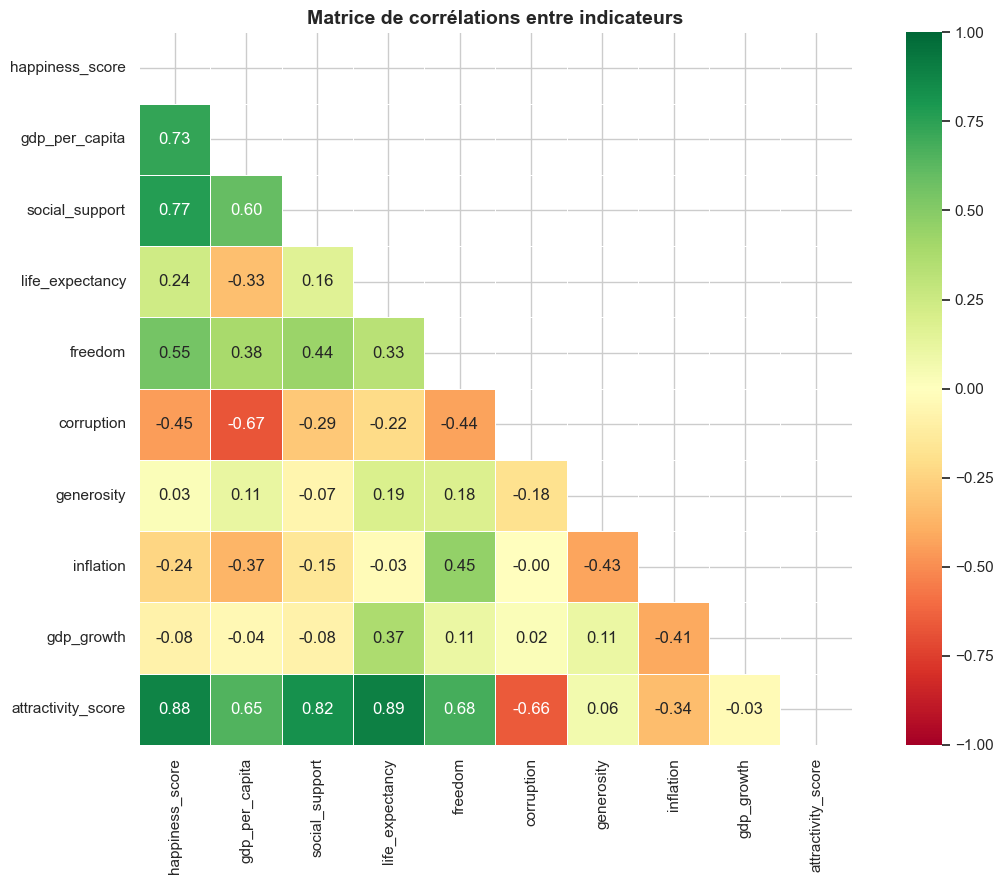


Corrélations avec happiness_score :
  attractivity_score             +0.878
  social_support                 +0.768
  gdp_per_capita                 +0.728
  freedom                        +0.549
  life_expectancy                +0.238
  generosity                     +0.031
  gdp_growth                     -0.080
  inflation                      -0.239
  corruption                     -0.449


In [6]:
corr_cols = ['happiness_score', 'gdp_per_capita', 'social_support',
             'life_expectancy', 'freedom', 'corruption', 'generosity',
             'inflation', 'gdp_growth', 'attractivity_score']
corr_available = [c for c in corr_cols if c in df.columns]
corr_matrix = df[corr_available].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Matrice de corrélations entre indicateurs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '03_correlation_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrélations avec happiness_score :')
corr_bonheur = corr_matrix['happiness_score'].drop('happiness_score').sort_values(ascending=False)
for col, val in corr_bonheur.items():
    print(f'  {col:<30} {val:+.3f}')

## 6. PIB vs Bonheur
> Existe-t-il une relation entre richesse économique et bonheur ?

Année utilisée : 2019 (89 pays)


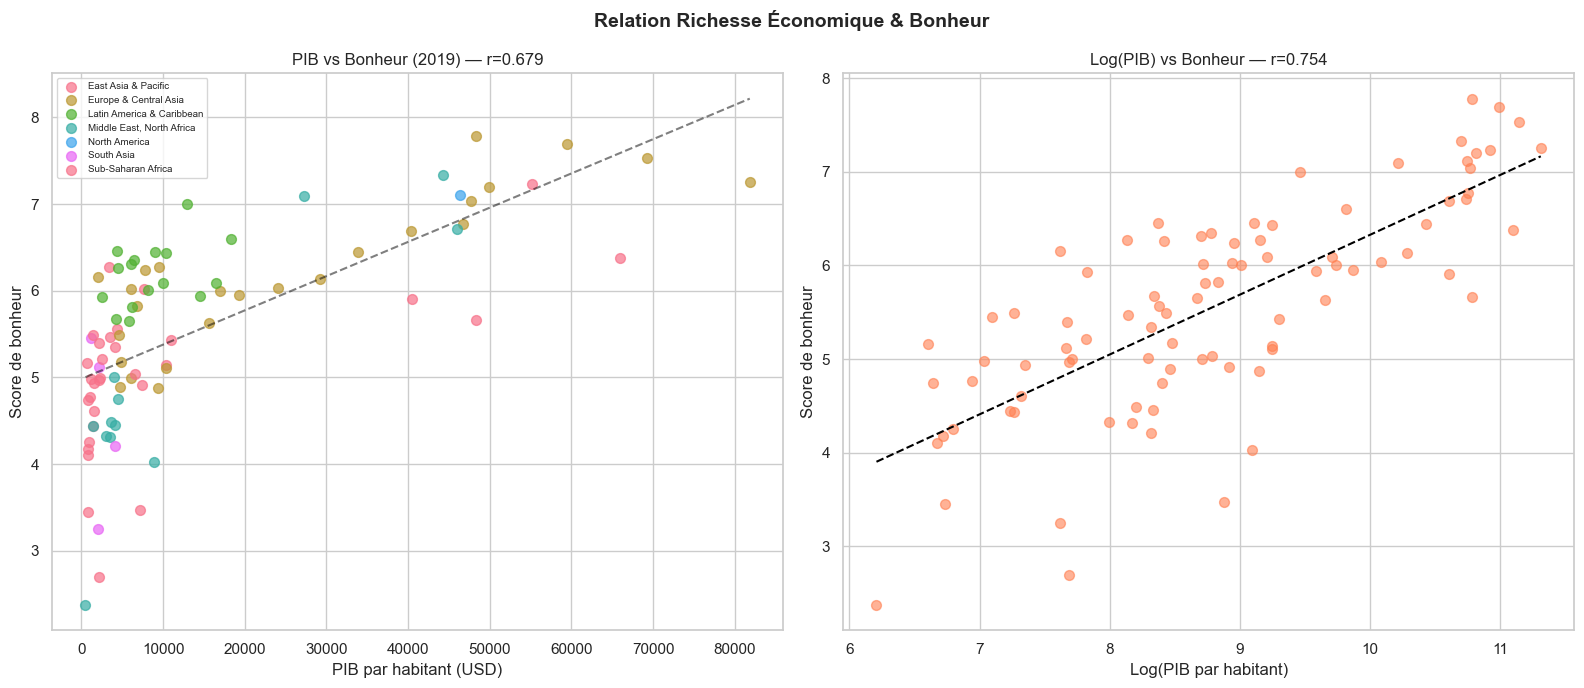

In [9]:
# Prendre l'année qui a le plus de données PIB
df_test = df.dropna(subset=['gdp_per_capita', 'happiness_score'])

if df_test.empty:
    print("⚠️ Pas de données PIB disponibles — lance d'abord fix_gdp.py")
else:
    # Choisir l'année avec le plus de données
    best_year = df_test.groupby('year').size().idxmax()
    df_latest = df_test[df_test['year'] == best_year].copy()
    print(f"Année utilisée : {best_year} ({len(df_latest)} pays)")

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    ax1 = axes[0]
    if 'region' in df_latest.columns:
        for region, grp in df_latest.groupby('region'):
            ax1.scatter(grp['gdp_per_capita'], grp['happiness_score'],
                       label=region[:25], alpha=0.7, s=50)
    x = df_latest['gdp_per_capita']
    y = df_latest['happiness_score']
    z = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax1.plot(x_line, np.poly1d(z)(x_line), 'k--', alpha=0.5)
    r, _ = stats.pearsonr(x, y)
    ax1.set_xlabel('PIB par habitant (USD)')
    ax1.set_ylabel('Score de bonheur')
    ax1.set_title(f'PIB vs Bonheur ({best_year}) — r={r:.3f}')
    ax1.legend(fontsize=7)

    ax2 = axes[1]
    df_latest['log_gdp'] = np.log(df_latest['gdp_per_capita'])
    x2 = df_latest['log_gdp']
    y2 = df_latest['happiness_score']
    ax2.scatter(x2, y2, alpha=0.6, color='coral', s=50)
    z2 = np.polyfit(x2, y2, 1)
    ax2.plot(np.linspace(x2.min(), x2.max(), 100),
             np.poly1d(z2)(np.linspace(x2.min(), x2.max(), 100)), 'k--')
    r2, _ = stats.pearsonr(x2, y2)
    ax2.set_xlabel('Log(PIB par habitant)')
    ax2.set_ylabel('Score de bonheur')
    ax2.set_title(f'Log(PIB) vs Bonheur — r={r2:.3f}')

    fig.suptitle('Relation Richesse Économique & Bonheur', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, '04_pib_vs_bonheur.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 7. Top 15 pays les plus heureux

Année utilisée : 2019
Nombre de pays : 15
              country_name  happiness_score
603                Finland            7.780
519                Denmark            7.693
893                Iceland            7.533
903                 Israel            7.332
863                Ireland            7.255
99               Australia            7.234
109                Austria            7.195
319                 Canada            7.109
189                Bahrain            7.098
489                Germany            7.035
429             Costa Rica            6.998
139                Belgium            6.772
50    United Arab Emirates            6.711
623                 France            6.690
1182               Uruguay            6.600


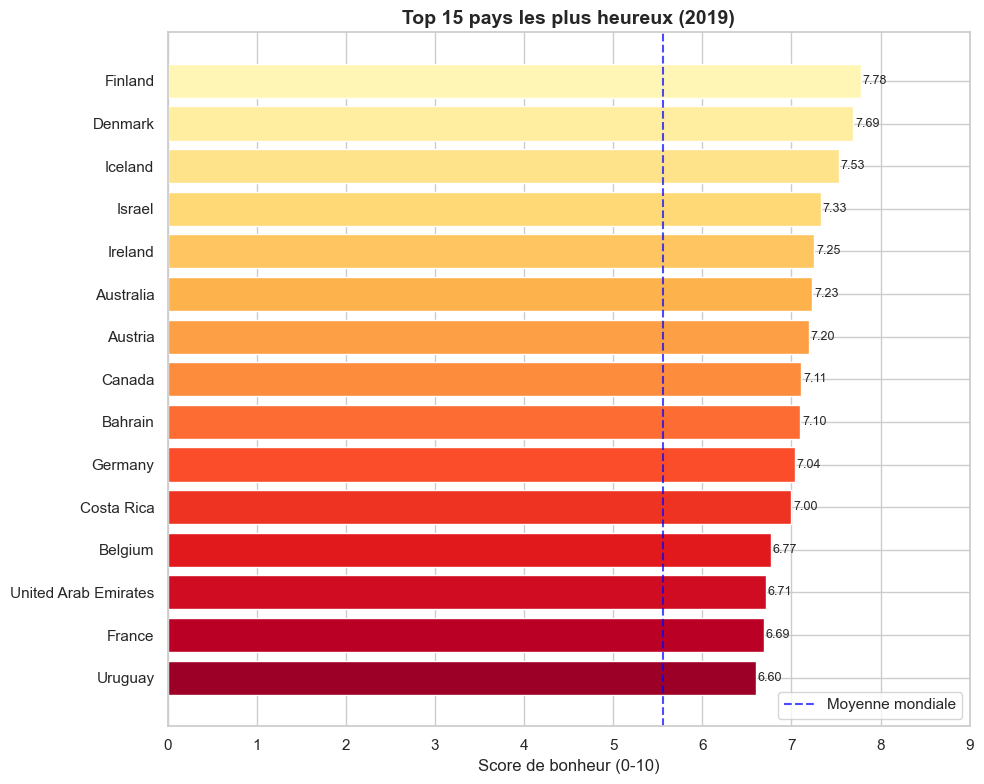

In [11]:
# Prendre l'année qui a le plus de données happiness
best_year_hap = df.dropna(subset=['happiness_score']).groupby('year').size().idxmax()
print(f"Année utilisée : {best_year_hap}")

df_top = (df[df['year'] == best_year_hap]
          .dropna(subset=['happiness_score'])
          .nlargest(15, 'happiness_score')
          [['country_name', 'happiness_score', 'gdp_per_capita', 'region']])

print(f"Nombre de pays : {len(df_top)}")
print(df_top[['country_name', 'happiness_score']].to_string())

fig, ax = plt.subplots(figsize=(10, 8))
colors = sns.color_palette('YlOrRd', len(df_top))
bars = ax.barh(df_top['country_name'][::-1], df_top['happiness_score'][::-1], color=colors[::-1])
ax.set_xlabel('Score de bonheur (0-10)')
ax.set_title(f'Top 15 pays les plus heureux ({best_year_hap})', fontsize=14, fontweight='bold')
ax.axvline(x=df[df['year'] == best_year_hap]['happiness_score'].mean(),
           color='blue', linestyle='--', label='Moyenne mondiale', alpha=0.7)
for bar, (_, row) in zip(bars[::-1], df_top.iterrows()):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f"{row['happiness_score']:.2f}", va='center', fontsize=9)
ax.legend()
ax.set_xlim(0, 9)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '05_top15_pays_heureux.png'), dpi=150, bbox_inches='tight')
plt.show()

## 8. Évolution temporelle par région

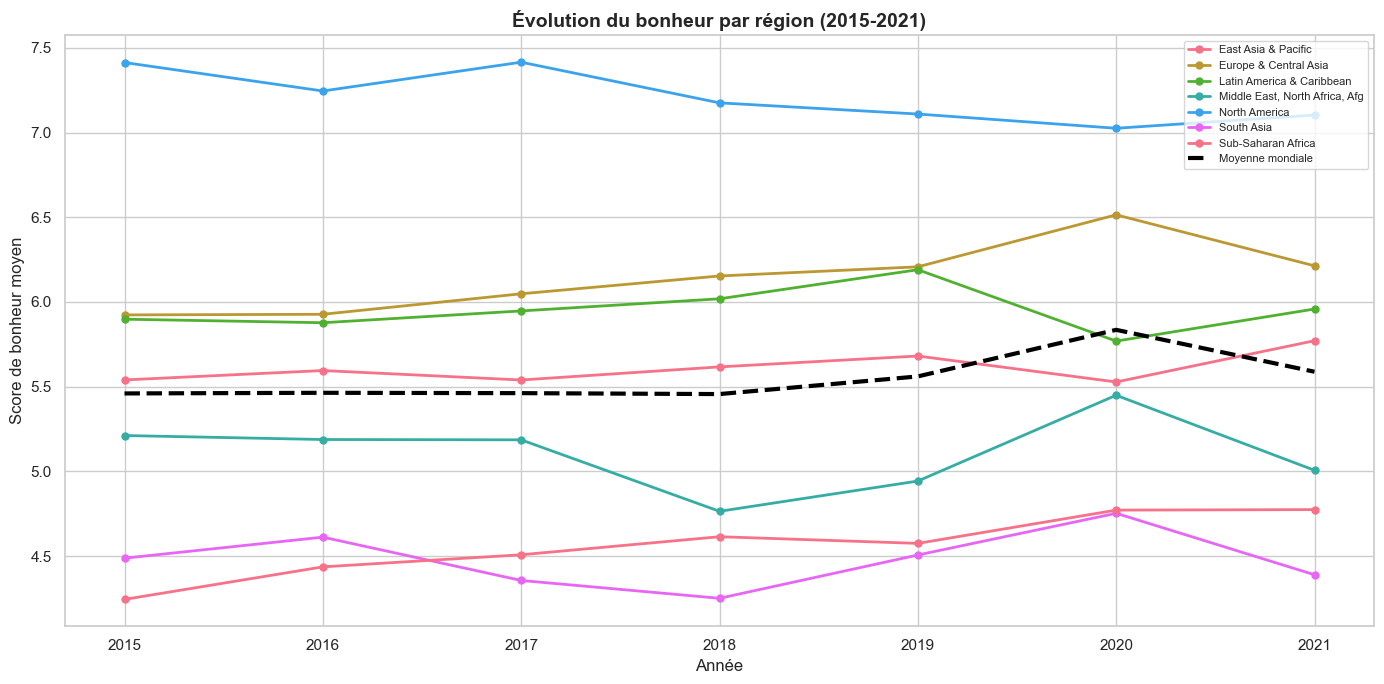

In [12]:
df_evo = df.groupby(['year', 'region'])['happiness_score'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
for region, grp in df_evo.groupby('region'):
    grp_sorted = grp.sort_values('year')
    ax.plot(grp_sorted['year'], grp_sorted['happiness_score'],
            marker='o', linewidth=2, markersize=5, label=region[:30])

df_world = df.groupby('year')['happiness_score'].mean().reset_index()
ax.plot(df_world['year'], df_world['happiness_score'],
        'k--', linewidth=3, label='Moyenne mondiale', zorder=5)

ax.set_xlabel('Année')
ax.set_ylabel('Score de bonheur moyen')
ax.set_title('Évolution du bonheur par région (2015-2021)', fontsize=14, fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '06_evolution_temporelle.png'), dpi=150, bbox_inches='tight')
plt.show()

## 9. Impact de la corruption sur le bonheur

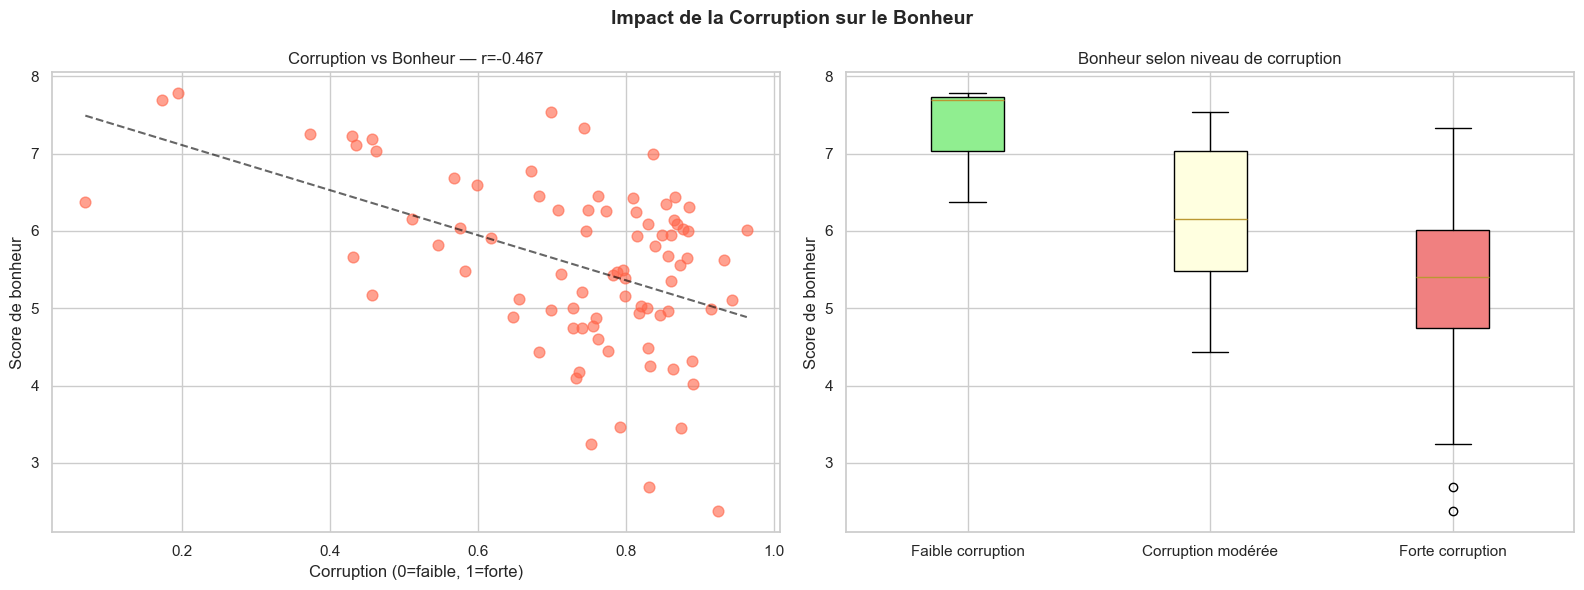

In [14]:
df_corr = df[(df['year'] == latest_year)].dropna(subset=['corruption', 'happiness_score']).copy()
df_corr['cat_corruption'] = pd.cut(df_corr['corruption'],
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Faible corruption', 'Corruption modérée', 'Forte corruption'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
ax1.scatter(df_corr['corruption'], df_corr['happiness_score'], alpha=0.6, color='tomato', s=60)
r, _ = stats.pearsonr(df_corr['corruption'], df_corr['happiness_score'])
z = np.polyfit(df_corr['corruption'], df_corr['happiness_score'], 1)
x_line = np.linspace(df_corr['corruption'].min(), df_corr['corruption'].max(), 100)
ax1.plot(x_line, np.poly1d(z)(x_line), 'k--', alpha=0.6)
ax1.set_xlabel('Corruption (0=faible, 1=forte)')
ax1.set_ylabel('Score de bonheur')
ax1.set_title(f'Corruption vs Bonheur — r={r:.3f}')

ax2 = axes[1]
cats = ['Faible corruption', 'Corruption modérée', 'Forte corruption']
data_boxes = [df_corr[df_corr['cat_corruption'] == c]['happiness_score'].values for c in cats]
bp = ax2.boxplot(data_boxes, labels=cats, patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightgreen', 'lightyellow', 'lightcoral']):
    patch.set_facecolor(color)
ax2.set_ylabel('Score de bonheur')
ax2.set_title('Bonheur selon niveau de corruption')

fig.suptitle('Impact de la Corruption sur le Bonheur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '07_corruption_vs_bonheur.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Score d'attractivité — Top 20 pays

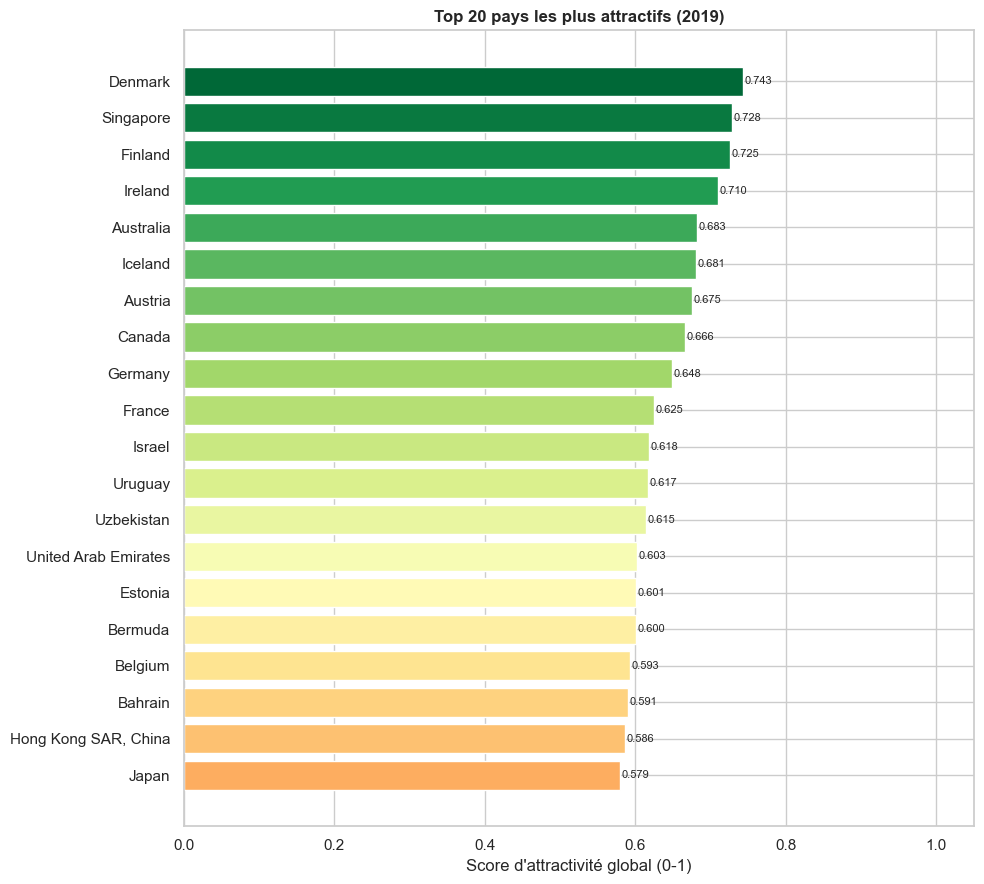


✅ EDA TERMINÉE — tous les graphiques sont dans reports/plots/


In [15]:
df_attr = (df[df['year'] == latest_year]
           .dropna(subset=['attractivity_score'])
           .sort_values('attractivity_score', ascending=False)
           .head(20))

fig, ax = plt.subplots(figsize=(10, 9))
colors = plt.cm.RdYlGn(np.linspace(0.3, 1, len(df_attr)))
bars = ax.barh(df_attr['country_name'][::-1], df_attr['attractivity_score'][::-1], color=colors)
ax.set_xlabel("Score d'attractivité global (0-1)")
ax.set_title(f'Top 20 pays les plus attractifs ({latest_year})', fontsize=12, fontweight='bold')
for bar, (_, row) in zip(bars[::-1], df_attr.iterrows()):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f"{row['attractivity_score']:.3f}", va='center', fontsize=8)
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, '08_top20_attractivite.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ EDA TERMINÉE — tous les graphiques sont dans reports/plots/')